## 📝 Practice Questions — t-Test Concepts

---

### 1️⃣ When should we use a t-test instead of a z-test?

A **t-test** is used when:

- The population standard deviation (σ) is **unknown**
- The sample size is **small** (typically n < 30)
- The data is approximately **normally distributed**

A **z-test** is used when σ is known and/or the sample size is large.

👉 In practice, σ is rarely known — so the **t-test is more common**.

---

### 2️⃣ Difference between one-tailed and two-tailed t-test

| Feature | One-Tailed t-Test | Two-Tailed t-Test |
|--------|------------------|----------------|
| Purpose | Tests difference in **one direction** | Tests for **any difference** |
| Hypothesis | μ > μ₀ or μ < μ₀ | μ ≠ μ₀ |
| Critical region | One side of distribution | Both sides |
| Sensitivity | More power in one direction | More general |

**Example**

- One-tailed → “Is the new method better?”
- Two-tailed → “Is the new method different?”

---

### 3️⃣ Difference between one-sample and two-sample t-test

| Feature | One-Sample t-Test | Two-Sample t-Test |
|--------|----------------|----------------|
| Comparison | Sample vs population mean | Two independent samples |
| Goal | Verify claim about a mean | Compare group means |
| Example | Battery life vs claim | Scores of two classes |

---

### 4️⃣ What is a pooled t-test and when is it used?

A **pooled t-test** assumes:

- Independent samples
- Equal population variances

It combines sample variances into a **pooled estimate**.

**Used when:**

- Variances are statistically similar
- Data is approximately normal

Benefit → More stable variance estimation.

---

### 5️⃣ What is Welch’s t-test and why is it preferred?

Welch’s t-test:

- Does **not assume equal variances**
- Adjusts degrees of freedom
- More robust with unequal sample sizes

**Preferred when:**

- Variances differ
- Sample sizes are unequal

It reduces incorrect conclusions.

---

### 6️⃣ How do degrees of freedom affect the t-test?

Degrees of freedom determine:

- Shape of the t-distribution
- Critical thresholds

Effects:

- Small df → wider distribution → stricter test
- Large df → approaches normal distribution

Thus df influences test accuracy.

---

### 7️⃣ Can two samples have the same mean but still fail a t-test? Why?

Yes.

Even equal means may show **no significance** due to:

- High variability
- Small sample size
- Overlapping distributions

A t-test evaluates:

> Difference relative to variability — not just means.

---


# Question 1: One-Sample t-Test (Two-Tailed)

### 📘 Scenario

## A coaching institute claims that the average mock test score of its students is 70 marks.
### A random sample of 12 students gives:
- Sample mean = 72 marks
- Sample standard deviation = 5 marks
- Test the claim at α = 0.05.

## 📝 Tasks
1. State H₀ and H₁
2. Calculate t-score manually
3. Compute p-value
4. Find critical t-value
5. Make a decision using:
6. Method-1 (p-value)
7. Method-2 (critical value)

In [11]:
from scipy.stats import t 
import numpy as np
x_bar = 72
mu = 70
s = 5
n = 12
alpha = 0.05

print("H0: μ = 70  (average score is 70)")
print("H1: μ ≠ 70  (average score is different from 70)\n")

t_score = (x_bar - mu) / (s/np.sqrt(n))
df = n - 1

p_value = 2 * (1 - t.cdf(abs(t_score), df))
t_critical = t.ppf(1 - alpha/2 , df)

print("t-score:", t_score)
print("p-value:", p_value)
print("critical t-value:", t_critical)

if p_value < alpha:
    print("\nReject H0")
else:
    print("\nFail to Reject H0")

if abs(t_score) > t_critical:
    print("Reject H0")
else:
    print("Fail to Reject H0")



H0: μ = 70  (average score is 70)
H1: μ ≠ 70  (average score is different from 70)

t-score: 1.3856406460551016
p-value: 0.19330705325122444
critical t-value: 2.200985160082949

Fail to Reject H0
Fail to Reject H0


- **Conclusion:**  At the 5% significance level, there is not enough evidence to say the average score is different from 70. Therefore, we fail to reject the coaching institute’s claim.

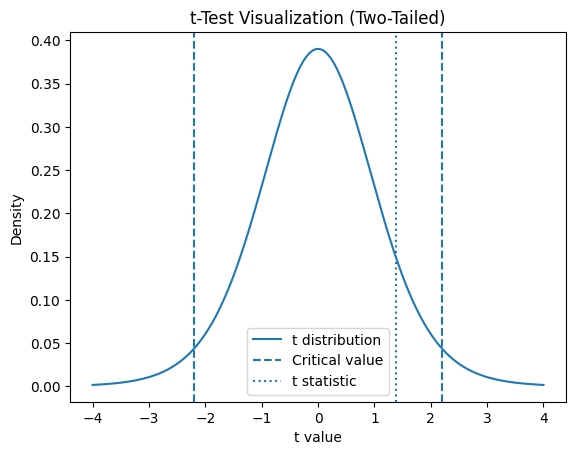

In [14]:
import matplotlib.pyplot as plt 
import seaborn as sns
x = np.linspace(-4, 4, 400)
y = t.pdf(x, df)

plt.figure()
plt.plot(x, y, label="t distribution")
plt.axvline(t_critical, linestyle="--", label="Critical value")
plt.axvline(-t_critical, linestyle="--")
plt.axvline(t_score, linestyle=":", label="t statistic")

plt.title("t-Test Visualization (Two-Tailed)")
plt.xlabel("t value")
plt.ylabel("Density")
plt.legend()
plt.show()

# Question 2: One-Sample t-Test (Right-Tailed)

## 📘 Scenario

### A company claims that the average daily working hours of its employees are more than 8 hours.

#### A sample of 10 employees shows:

- Sample mean = 8.6 hours
- Sample standard deviation = 0.9 hours
- Test the claim at α = 0.05.

### 📝 Tasks

1. Frame right-tailed hypotheses
2. Compute t-statistic
3. Calculate one-tailed p-value
4. Determine critical t-value
5. Decide using both methods
- Interpret the result as a management insight

In [21]:
X_bar = 8.6
mu = 8
s = 0.9
n = 10
alpha = 0.05

print("H0: μ ≤ 8")
print("H1: μ > 8\n")

SE = s/np.sqrt(n)
t_score = (x_bar - mu) / SE 
print("t-statistic =", round(t_score, 4))


df =  n-1 

p_value = 1 - t.cdf(t_score, df)
print("p-value : ",round(p_value,4))

t_critical = t.ppf(1-alpha, df)
print("Critical t-value : ",round(t_critical,4))

print("\nConclusion:")
if p_value < alpha and t_score > t_critical:
    print("Reject H0")
    print("There is enough evidence that employees work more than 8 hours on average.")
else:
    print("Fail to Reject H0")
    print("There is not enough evidence to say employees work more than 8 hours on average.")


H0: μ ≤ 8
H1: μ > 8

t-statistic = 2.1082
p-value :  0.0321
Critical t-value :  1.8331

Conclusion:
Reject H0
There is enough evidence that employees work more than 8 hours on average.


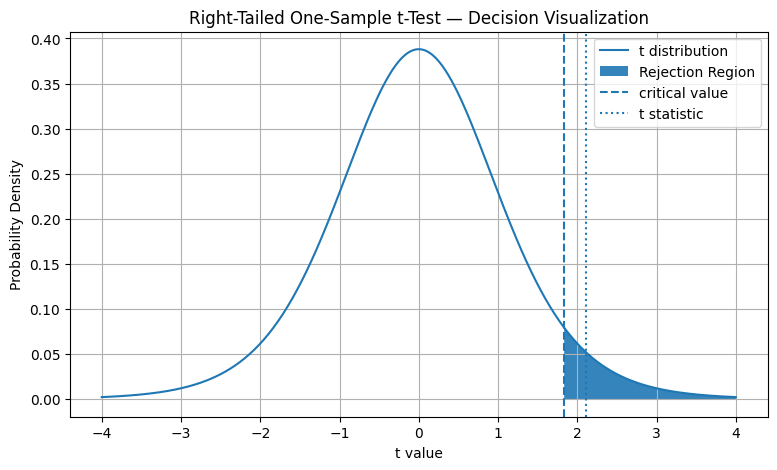

In [38]:
x = np.linspace(-4, 4, 400)
y = t.pdf(x, df)
plt.figure(figsize=(9, 5))
plt.plot(x, y, label="t distribution")

plt.fill_between(x, y, where=(x >= t_critical),alpha=0.9, label="Rejection Region")

plt.axvline(t_critical, linestyle="--", label="critical value")
plt.axvline(t_score, linestyle=":", label="t statistic")

plt.title("Right-Tailed One-Sample t-Test — Decision Visualization")
plt.xlabel("t value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

 # Question 3: Two-Sample t-Test (Pooled / Equal Variance)

### 📘 Scenario

#### Two batches of students are trained using the same syllabus.

- **Batch A** => Sample Mean=68, Std=4, n=8

- **Batch B** => Sample Mean=64, Std=4, n=8

- Assume equal population variances.
- Test whether there is a significant difference at α = 0.05.

### 📝 Tasks
1. State H₀ and H₁
2. Justify why pooled t-test is applicable
3. Compute pooled variance
4. Calculate t-score
5. Find p-value

- Apply:
1. Method-1 (p-value)
2. Method-2 (critical t)
- Write final conclusion

In [43]:
import math
from scipy.stats import t

print("=== Two-Sample t-Test (Pooled / Equal Variance) ===\n")

print("H0: μA = μB  (no significant difference)")
print("H1: μA ≠ μB  (significant difference)\n")

x1 = 68
s1 = 4
n1 = 8

x2 = 64
s2 = 4
n2 = 8

alpha = 0.05

# Pooled variance
sp2 = (((n1 - 1)*(s1**2)) + ((n2 - 1)*(s2**2))) / (n1 + n2 - 2)
sp = math.sqrt(sp2)

print("Pooled Variance =", round(sp2, 4))
print("Pooled Std Dev =", round(sp, 4), "\n")

# t statistic
se = sp * math.sqrt(1/n1 + 1/n2)
t_score = (x1 - x2) / se
print("t-score =", round(t_score, 4), "\n")

# Degrees of freedom
df = n1 + n2 - 2

# p-value (two-tailed)
p_value = 2 * (1 - t.cdf(abs(t_score), df))
print("p-value =", round(p_value, 4), "\n")

# Critical value
t_critical = t.ppf(1 - alpha/2, df)
print("Critical t-value = ±", round(t_critical, 4), "\n")

print("\nConclusion:")
if p_value < alpha and t_score > t_critical:
    print("Reject H0")
    print("There is a significant difference between the two batches.")
else :
    print("Fail to Reject H0")
    print("There is no significant difference between the two batches.")

=== Two-Sample t-Test (Pooled / Equal Variance) ===

H0: μA = μB  (no significant difference)
H1: μA ≠ μB  (significant difference)

Pooled Variance = 16.0
Pooled Std Dev = 4.0 

t-score = 2.0 

p-value = 0.0653 

Critical t-value = ± 2.1448 


Conclusion:
Fail to Reject H0
There is no significant difference between the two batches.


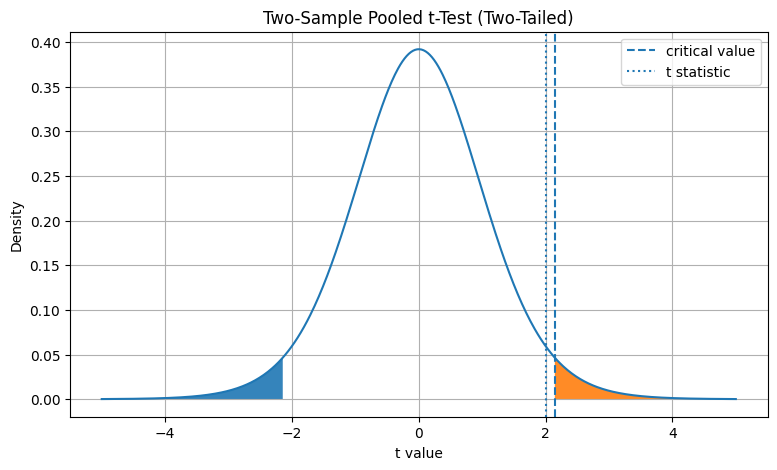

In [53]:
x = np.linspace(-5, 5, 600)
y = t.pdf(x, df)


plt.figure(figsize=(9, 5))
# t curve
plt.plot(x, y)

# rejection regions
plt.fill_between(x, y, where=(x <= -t_critical),alpha=0.9)
plt.fill_between(x, y, where=(x >= t_critical),alpha=0.9)

# lines
plt.axvline(t_critical, linestyle="--", label="critical value")
plt.axvline(t_score, linestyle=":", label="t statistic")

plt.title("Two-Sample Pooled t-Test (Two-Tailed)")
plt.xlabel("t value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


# Question 4: Two-Sample t-Test (Welch’s t-Test)

### 📘 Scenario
#### Two teams are compared based on project completion time (days).

- **Team A** => Mean=15, Std=2, n=6
- **Team B** => Mean=11, Std=4, n=8
- Variances are not equal.

### 📝 Tasks
1. Write H₀ and H₁
2. Explain why Welch’s t-test is required
3. Compute t-statistic
4. Calculate Welch degrees of freedom
5. Compute p-value
6. Make a decision using both methods
- Interpret the result in technical + non-technical language

In [56]:
print("=== Welch's Two-Sample t-Test ===\n")

# Hypotheses
print("H0: μ1 = μ2")
print("H1: μ1 ≠ μ2\n")

x1, s1, n1 = 15, 2, 6
x2, s2, n2 = 11, 4, 8
alpha = 0.05

# t statistic
se = math.sqrt((s1**2)/n1 + (s2**2)/n2)
t_score = (x1 - x2) / se

print("t-statistic =", round(t_score, 4))

# Welch df
num = ((s1**2)/n1 + (s2**2)/n2)**2
den = ((s1**2/n1)**2)/(n1-1) + ((s2**2/n2)**2)/(n2-1)
df = num / den

print("Welch df =", round(df, 2))

# p-value
p_value = 2 * (1 - t.cdf(abs(t_score), df))
print("p-value =", round(p_value, 4))

# critical value
t_critical = t.ppf(1 - alpha/2, df)
print("critical value = ±", round(t_critical, 4), "\n")

# decisions
print("\nConclusion:")
if p_value < alpha and t_score > t_critical:
    print("Reject H0")
    print("There is a significant difference between the two batches.")
else :
    print("Fail to Reject H0")
    print("There is no significant difference between the two batches.")
    

=== Welch's Two-Sample t-Test ===

H0: μ1 = μ2
H1: μ1 ≠ μ2

t-statistic = 2.4495
Welch df = 10.77
p-value = 0.0327
critical value = ± 2.2068 


Conclusion:
Reject H0
There is a significant difference between the two batches.


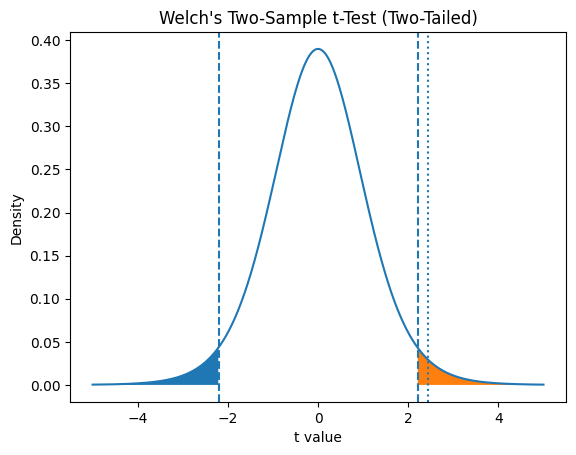

In [57]:

# Graph range
x = np.linspace(-5, 5, 600)
y = t.pdf(x, df)

plt.figure()

# t distribution curve
plt.plot(x, y)

# rejection regions
plt.fill_between(x, y, where=(x <= -t_critical))
plt.fill_between(x, y, where=(x >= t_critical))

# vertical lines
plt.axvline(t_score, linestyle=":")
plt.axvline(t_critical, linestyle="--")
plt.axvline(-t_critical, linestyle="--")

plt.title("Welch's Two-Sample t-Test (Two-Tailed)")
plt.xlabel("t value")
plt.ylabel("Density")

plt.show()

# Question 5: Two-Sample t-Test (Left-Tailed) 

## 📘 Scenario
#### A new teaching method claims to reduce average learning time compared to the old method.

- Method Old => Mean (hrs)=9.5, Std=1.2, n=7
- Method New => Mean (hrs)=8.2, Std=1.1, n=7
- Test the claim at α = 0.05.

### 📝 Tasks
1. Frame left-tailed hypotheses
2. Calculate t-score
3. Compute one-tailed p-value
4. Identify critical t-value

- Apply:
1. Method-1 (p-value)
2. Method-2 (critical value)
- State final conclusion clearly 

In [65]:

print("=== Two-Sample Left-Tailed t-Test ===\n")

print("Step 1: Hypotheses")
print("H0: μ_new ≥ μ_old  (no reduction in learning time)")
print("H1: μ_new < μ_old  (new method reduces learning time)\n")
old_mean = 9.5
old_sd = 1.2
n1 = 7

new_mean = 8.2
new_sd = 1.1
n2 = 7

alpha = 0.05
sp2 = (((n1 - 1)*(old_sd**2)) + ((n2 - 1)*(new_sd**2))) / (n1 + n2 - 2)
sp = math.sqrt(sp2)

se = sp * math.sqrt(1/n1 + 1/n2)
t_score = (new_mean - old_mean) / se

print("t-statistic =", round(t_score, 4))

df = n1 + n2 - 2
p_value = t.cdf(t_score, df)
print("p-value =", round(p_value, 4))

t_critical = t.ppf(alpha, df)
print("critical t-value =", round(t_critical, 4), "\n")

print("\nConclusion:")
if p_value < alpha or t_score < t_critical:
    print("Reject H0")
    print("The new teaching method significantly reduces learning time.")
else:
    print("Fail to Reject H0")
    print("There is not enough evidence that the new method reduces learning time.")


=== Two-Sample Left-Tailed t-Test ===

Step 1: Hypotheses
H0: μ_new ≥ μ_old  (no reduction in learning time)
H1: μ_new < μ_old  (new method reduces learning time)

t-statistic = -2.1129
p-value = 0.0281
critical t-value = -1.7823 


Conclusion:
Reject H0
The new teaching method significantly reduces learning time.


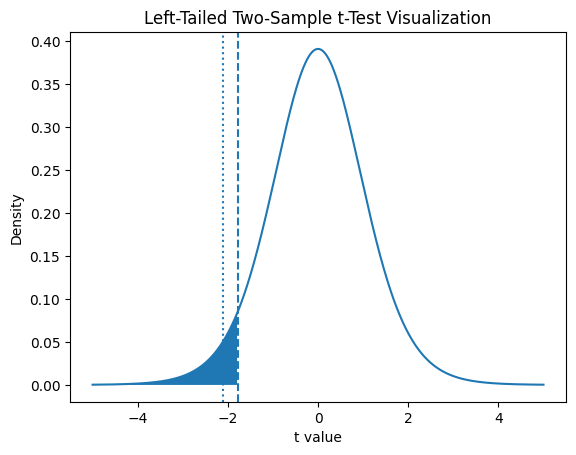

In [67]:
x = np.linspace(-5, 5, 600)
y = t.pdf(x, df)

plt.figure()

# t distribution curve
plt.plot(x, y)

# rejection region (left tail)
plt.fill_between(x, y, where=(x <= t_critical))

# vertical lines
plt.axvline(t_score, linestyle=":")
plt.axvline(t_critical, linestyle="--")

plt.title("Left-Tailed Two-Sample t-Test Visualization")
plt.xlabel("t value")
plt.ylabel("Density")
plt.show()
